# 04 — Modeling v2 (Spatial Cross-Validation)

Inputs: `train_v2.csv`, `test_v2.csv`, `selected_features_v2.json`

Changes vs v1:
- **`GroupKFold(n_splits=5)`** using spatial block IDs (vs `StratifiedKFold(n_splits=10)`)
- Holdout test = spatially separate blocks (no leakage)
- Expected AUC: 0.75 – 0.90 (proper spatial CV, vs ~0.997 with geographic confounding)

Final cell shows **v1 vs v2 AUC comparison** to document the confounding effect.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid', font_scale=1.1)

PROCESSED  = Path('../data/processed')
OUTPUTS    = Path('../outputs')
MODELS_DIR = Path('../models')
MLRUNS_DIR = Path('../mlruns')
OUTPUTS.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS     = 5
EXPERIMENT   = 'wildfires-cordoba'

print('All imports OK')

All imports OK


## 1. Load Data

In [2]:
with open(PROCESSED / 'selected_features_v2.json') as f:
    feature_meta = json.load(f)

MODEL_FEATURES = feature_meta['all_model_features']

train = pd.read_csv(PROCESSED / 'train_v2.csv')
test  = pd.read_csv(PROCESSED / 'test_v2.csv')

X_train       = train[MODEL_FEATURES].values
y_train       = train['label'].values
block_ids_train = train['block_id'].values  # for GroupKFold

X_test  = test[MODEL_FEATURES].values
y_test  = test['label'].values

print(f'Train: {X_train.shape}  fire_rate={y_train.mean():.4f}  blocks={train["block_id"].nunique()}')
print(f'Test : {X_test.shape}   fire_rate={y_test.mean():.4f}   blocks={test["block_id"].nunique()}')
print(f'Features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}')

Train: (52904, 19)  fire_rate=0.5262  blocks=321
Test : (19392, 19)   fire_rate=0.4285   blocks=138
Features (19): ['elevation', 'slope', 'aspect_cos', 'population_density', 'clay', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km', 'lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']


## 2. MLflow Setup

In [3]:
mlflow.set_tracking_uri(f'file://{MLRUNS_DIR.resolve()}')
mlflow.set_experiment(EXPERIMENT)

exp = mlflow.get_experiment_by_name(EXPERIMENT)
print(f'Experiment: {EXPERIMENT}  (ID: {exp.experiment_id})')

Experiment: wildfires-cordoba  (ID: 310954585512672985)


## 3. Evaluation Helpers

In [4]:
GKF = GroupKFold(n_splits=CV_FOLDS)

SCORING = {
    'roc_auc'  : 'roc_auc',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
}


def evaluate_on_test(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        'test_roc_auc'  : roc_auc_score(y_test, y_prob),
        'test_accuracy' : accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred, zero_division=0),
        'test_recall'   : recall_score(y_test, y_pred, zero_division=0),
        'test_f1'       : f1_score(y_test, y_pred, zero_division=0),
    }


def train_and_log_v2(name, model):
    """GroupKFold CV + holdout eval + MLflow logging."""
    print(f'Training {name}...', end=' ', flush=True)

    cv_results = cross_validate(
        model, X_train, y_train,
        cv=GKF,
        groups=block_ids_train,
        scoring=SCORING,
        return_train_score=False,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    holdout     = evaluate_on_test(model, X_test, y_test)
    cv_auc_mean = cv_results['test_roc_auc'].mean()
    cv_auc_std  = cv_results['test_roc_auc'].std()
    print(f'CV AUC={cv_auc_mean:.4f} ± {cv_auc_std:.4f}  |  Test AUC={holdout["test_roc_auc"]:.4f}')

    with mlflow.start_run(run_name=f'{name}_v2_baseline') as run:
        mlflow.set_tag('phase',   'v2_baseline')
        mlflow.set_tag('model',   name)
        mlflow.set_tag('cv_type', 'GroupKFold_spatial')
        for k, v in model.get_params().items():
            mlflow.log_param(k, v)
        for metric in SCORING:
            mlflow.log_metric(f'cv_{metric}_mean', cv_results[f'test_{metric}'].mean())
            mlflow.log_metric(f'cv_{metric}_std',  cv_results[f'test_{metric}'].std())
        for k, v in holdout.items():
            mlflow.log_metric(k, v)
        mlflow.sklearn.log_model(model, artifact_path='model')
        run_id = run.info.run_id

    return {
        'name'        : name,
        'model'       : model,
        'run_id'      : run_id,
        'cv_auc_mean' : cv_auc_mean,
        'cv_auc_std'  : cv_auc_std,
        'cv_acc_mean' : cv_results['test_accuracy'].mean(),
        'cv_prec_mean': cv_results['test_precision'].mean(),
        'cv_rec_mean' : cv_results['test_recall'].mean(),
        'cv_f1_mean'  : cv_results['test_f1'].mean(),
        **holdout,
    }

print('Helper functions defined.')

Helper functions defined.


## 4. Baseline Models (Spatial GroupKFold CV)

Default hyperparameters — no tuning. Goal: AUC in 0.75–0.90 range with proper spatial CV.

In [5]:
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
result_rf = train_and_log_v2('RandomForest', rf)

Training RandomForest... 

CV AUC=0.7432 ± 0.0241  |  Test AUC=0.6992


2026/04/06 20:19:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/06 20:19:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [6]:
xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE
)
result_xgb = train_and_log_v2('XGBoost', xgb)

Training XGBoost... 

2026/04/06 20:19:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/06 20:19:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


CV AUC=0.7321 ± 0.0244  |  Test AUC=0.6912


In [7]:
lgbm = LGBMClassifier(
    n_estimators=200, learning_rate=0.1, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
)
result_lgbm = train_and_log_v2('LightGBM', lgbm)

Training LightGBM... 

2026/04/06 20:20:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/06 20:20:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


CV AUC=0.7283 ± 0.0293  |  Test AUC=0.6865


## 5. Comparison Table & Plots

In [8]:
results_v2 = [result_rf, result_xgb, result_lgbm]

metrics_df = pd.DataFrame([{
    'Model'   : r['name'],
    'CV AUC'  : f"{r['cv_auc_mean']:.4f} ± {r['cv_auc_std']:.4f}",
    'CV Acc'  : f"{r['cv_acc_mean']:.4f}",
    'CV F1'   : f"{r['cv_f1_mean']:.4f}",
    'Test AUC': f"{r['test_roc_auc']:.4f}",
    'Test Acc': f"{r['test_accuracy']:.4f}",
    'Test F1' : f"{r['test_f1']:.4f}",
} for r in results_v2])
metrics_df.set_index('Model', inplace=True)
print('=== V2 SPATIAL CV BASELINE ===')
print(metrics_df.to_string())
metrics_df

=== V2 SPATIAL CV BASELINE ===
                       CV AUC  CV Acc   CV F1 Test AUC Test Acc Test F1
Model                                                                  
RandomForest  0.7432 ± 0.0241  0.6792  0.6790   0.6992   0.6454  0.5690
XGBoost       0.7321 ± 0.0244  0.6743  0.6720   0.6912   0.6376  0.5584
LightGBM      0.7283 ± 0.0293  0.6704  0.6669   0.6865   0.6395  0.5585


,CV AUC,CV Acc,CV F1,Test AUC,Test Acc,Test F1
Model,,,,,,
RandomForest,0.7432 ± 0.0241,0.6792,0.6790,0.6992,0.6454,0.5690
XGBoost,0.7321 ± 0.0244,0.6743,0.6720,0.6912,0.6376,0.5584
LightGBM,0.7283 ± 0.0293,0.6704,0.6669,0.6865,0.6395,0.5585


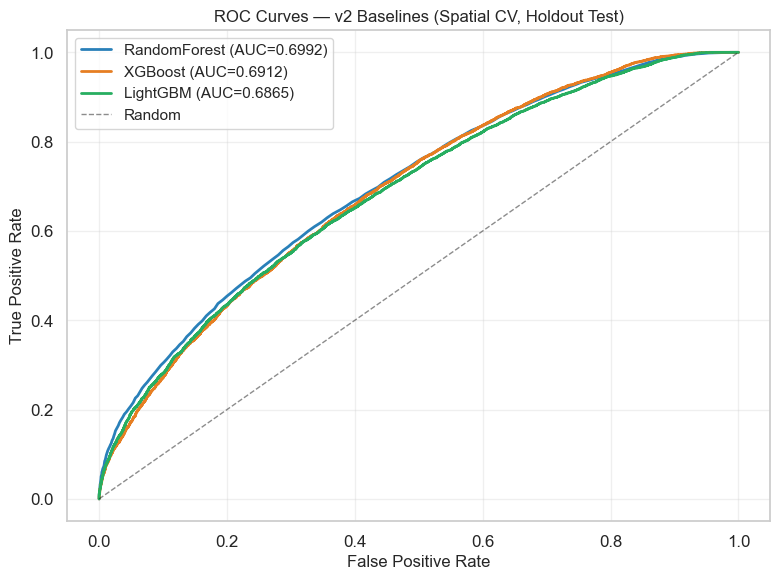

In [9]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2980b9', '#e67e22', '#27ae60']
for r, color in zip(results_v2, colors):
    y_prob    = r['model'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{r['name']} (AUC={r['test_roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — v2 Baselines (Spatial CV, Holdout Test)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

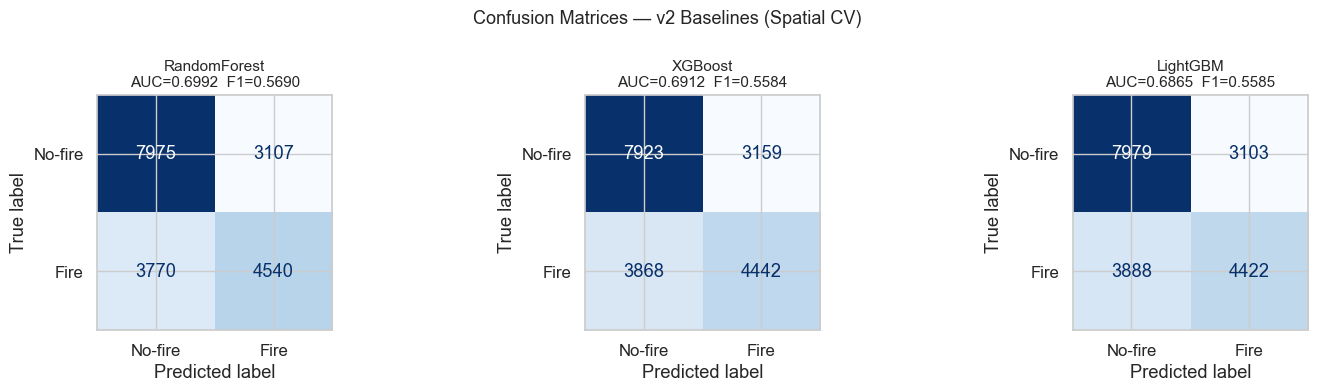

In [10]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for r, ax in zip(results_v2, axes):
    y_pred = r['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No-fire', 'Fire'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['name']}\nAUC={r['test_roc_auc']:.4f}  F1={r['test_f1']:.4f}",
                 fontsize=11)
plt.suptitle('Confusion Matrices — v2 Baselines (Spatial CV)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

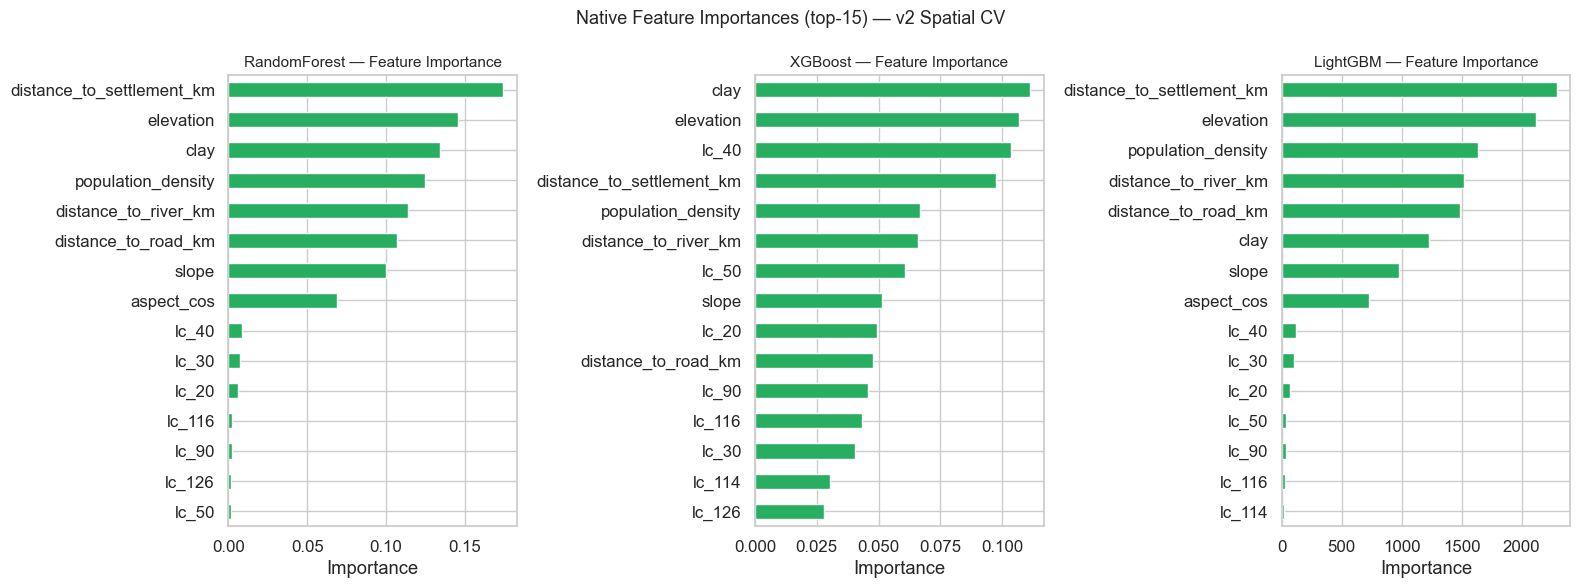

In [11]:
# Feature importances
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for r, ax in zip(results_v2, axes):
    model = r['model']
    imp   = model.feature_importances_ if hasattr(model, 'feature_importances_') \
            else np.zeros(len(MODEL_FEATURES))
    imp_df = pd.Series(imp, index=MODEL_FEATURES).sort_values(ascending=True).tail(15)
    imp_df.plot(kind='barh', ax=ax, color='#27ae60')
    ax.set_title(f"{r['name']} — Feature Importance", fontsize=11)
    ax.set_xlabel('Importance')
plt.suptitle('Native Feature Importances (top-15) — v2 Spatial CV', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. v1 vs v2 AUC Comparison

This table is the key evidence of geographic confounding.
The AUC drop from v1 (random CV, biased sampling) to v2 (spatial CV, elevation-stratified)
quantifies how much of the v1 performance was spurious.

In [12]:
# Load v1 metrics
with open(OUTPUTS / 'baseline_metrics.json') as f:
    v1_metrics = json.load(f)
v1_df = pd.DataFrame(v1_metrics)[['model', 'cv_auc_mean', 'test_roc_auc']]
v1_df.columns = ['Model', 'v1_CV_AUC', 'v1_Test_AUC']

# Build v2 metrics
v2_df = pd.DataFrame([{
    'Model'       : r['name'],
    'v2_CV_AUC'   : r['cv_auc_mean'],
    'v2_Test_AUC' : r['test_roc_auc'],
} for r in results_v2])

comparison = v1_df.merge(v2_df, on='Model')
comparison['CV_AUC_drop']   = comparison['v1_CV_AUC']   - comparison['v2_CV_AUC']
comparison['Test_AUC_drop'] = comparison['v1_Test_AUC'] - comparison['v2_Test_AUC']
comparison.set_index('Model', inplace=True)

print('=== v1 vs v2 AUC COMPARISON ===')
print('v1 = random StratifiedKFold(10) + 5km buffer (geographically confounded)')
print('v2 = spatial GroupKFold(5) + 1km buffer + elevation stratification')
print()
print(comparison.round(4).to_string())

=== v1 vs v2 AUC COMPARISON ===
v1 = random StratifiedKFold(10) + 5km buffer (geographically confounded)
v2 = spatial GroupKFold(5) + 1km buffer + elevation stratification

              v1_CV_AUC  v1_Test_AUC  v2_CV_AUC  v2_Test_AUC  CV_AUC_drop  Test_AUC_drop
Model                                                                                   
RandomForest     0.9965       0.9973     0.7432       0.6992       0.2533         0.2981
XGBoost          0.9908       0.9917     0.7321       0.6912       0.2586         0.3005
LightGBM         0.9961       0.9967     0.7283       0.6865       0.2679         0.3102


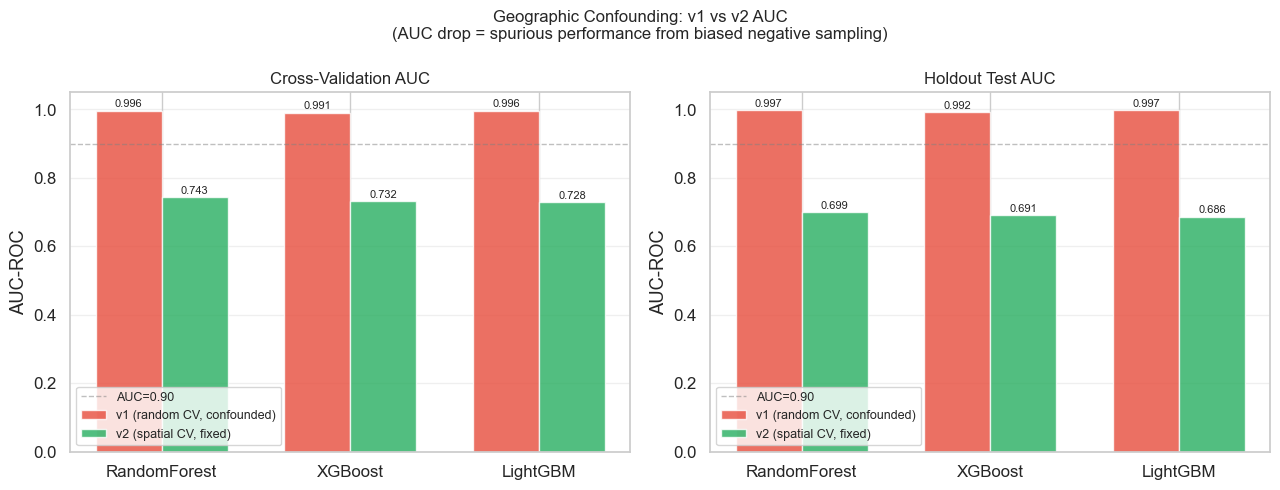

In [13]:
# Bar chart: AUC comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = comparison.index.tolist()
x = np.arange(len(models))
width = 0.35

for ax, v1_col, v2_col, title in [
    (axes[0], 'v1_CV_AUC',   'v2_CV_AUC',   'Cross-Validation AUC'),
    (axes[1], 'v1_Test_AUC', 'v2_Test_AUC', 'Holdout Test AUC'),
]:
    bars1 = ax.bar(x - width/2, comparison[v1_col], width, label='v1 (random CV, confounded)',
                   color='#e74c3c', alpha=0.8)
    bars2 = ax.bar(x + width/2, comparison[v2_col], width, label='v2 (spatial CV, fixed)',
                   color='#27ae60', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.9, ls='--', color='gray', alpha=0.5, lw=1, label='AUC=0.90')
    ax.set_ylabel('AUC-ROC')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # Annotate bars
    for bar in [*bars1, *bars2]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Geographic Confounding: v1 vs v2 AUC\n'
             '(AUC drop = spurious performance from biased negative sampling)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v1_vs_v2_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save v2 Results

In [14]:
# Save per-model files
for r in results_v2:
    p = MODELS_DIR / f'{r["name"].lower()}_v2_baseline.pkl'
    with open(p, 'wb') as f:
        pickle.dump(r['model'], f)
    print(f'Saved: {p}')

# Save metrics
v2_summary = [{
    'model'         : r['name'],
    'cv_auc_mean'   : r['cv_auc_mean'],
    'cv_auc_std'    : r['cv_auc_std'],
    'test_roc_auc'  : r['test_roc_auc'],
    'test_accuracy' : r['test_accuracy'],
    'test_precision': r['test_precision'],
    'test_recall'   : r['test_recall'],
    'test_f1'       : r['test_f1'],
    'run_id'        : r['run_id'],
} for r in results_v2]

with open(OUTPUTS / 'v2_baseline_metrics.json', 'w') as f:
    json.dump(v2_summary, f, indent=2)
print('Saved: outputs/v2_baseline_metrics.json')

Saved: ../models/randomforest_v2_baseline.pkl
Saved: ../models/xgboost_v2_baseline.pkl
Saved: ../models/lightgbm_v2_baseline.pkl
Saved: outputs/v2_baseline_metrics.json


## 8. Verification

In [15]:
print('=== MODELING V2 VERIFICATION ===')

# AUC floor (below 0.65 = over-corrected)
for r in results_v2:
    assert r['test_roc_auc'] > 0.65, f'{r["name"]} AUC too low: {r["test_roc_auc"]:.4f}'
    flag = ' < SUSPICIOUS (check over-correction)' if r['test_roc_auc'] > 0.97 else ''
    print(f'  [OK] {r["name"]} test AUC = {r["test_roc_auc"]:.4f} > 0.65{flag}')

# AUC drop vs v1
print()
for _, row in comparison.iterrows():
    drop = row['Test_AUC_drop']
    symbol = 'OK' if drop > 0.02 else 'WARN'
    print(f'  [{symbol}] {row.name}: Test AUC drop = {drop:.4f} '
          f'(v1={row["v1_Test_AUC"]:.4f} → v2={row["v2_Test_AUC"]:.4f})')

# No block leakage
train_b = set(train['block_id'])
test_b  = set(test['block_id'])
assert len(train_b & test_b) == 0
print(f'\n  [OK] No spatial block overlap (train={len(train_b)}, test={len(test_b)} blocks)')

# Files saved
assert (OUTPUTS / 'v2_baseline_metrics.json').exists()
print('  [OK] v2_baseline_metrics.json saved')

best_v2 = max(results_v2, key=lambda r: r['test_roc_auc'])
print(f'\nBest v2 model: {best_v2["name"]} (Test AUC={best_v2["test_roc_auc"]:.4f})')

=== MODELING V2 VERIFICATION ===
  [OK] RandomForest test AUC = 0.6992 > 0.65
  [OK] XGBoost test AUC = 0.6912 > 0.65
  [OK] LightGBM test AUC = 0.6865 > 0.65

  [OK] RandomForest: Test AUC drop = 0.2981 (v1=0.9973 → v2=0.6992)
  [OK] XGBoost: Test AUC drop = 0.3005 (v1=0.9917 → v2=0.6912)
  [OK] LightGBM: Test AUC drop = 0.3102 (v1=0.9967 → v2=0.6865)

  [OK] No spatial block overlap (train=321, test=138 blocks)
  [OK] v2_baseline_metrics.json saved

Best v2 model: RandomForest (Test AUC=0.6992)
